In [1]:

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder2D
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# Ground truth system model
gt_model = DoubleIntegrator2D()
# Sampling rate
ts = gt_model.params[1]["ts"]

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = -2.
umax = +2.
xmin = -5.
xmax = +5.


In [3]:
# build library once
lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=False,
    include_bias=True, max_degree=2,
    add_sqrt=False, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
sindy = SINDyVectorized(library=lib, n_out=nx, device=device)


In [4]:
sindy.pretty_print()

dx0/dt = -2.9910e-02·1 + -1.0044e-02·x0 + +1.0372e-02·x1 + +3.4506e-02·x2 + -3.2436e-02·x3 + +1.4281e-03·u0 + -4.0143e-02·u1 + +2.4467e-02·x0^2 + +1.9618e-03·x0*x1 + -6.8827e-03·x0*x2 + +1.4697e-02·x0*x3 + -7.2181e-03·x1^2 + -4.2336e-02·x1*x2 + -7.4797e-03·x1*x3 + +2.4931e-02·x2^2 + +1.3799e-02·x2*x3 + -1.6075e-02·x3^2 + -3.5907e-02·u0*u1 + +2.8982e-03·x0*u0 + -1.4553e-02·x0*u1 + -1.2746e-03·x1*u0 + +4.0111e-02·x1*u1 + +3.2365e-02·x2*u0 + -1.8827e-02·x2*u1 + -2.2537e-02·x3*u0 + +2.8644e-02·x3*u1
dx1/dt = +8.6101e-04·1 + -4.4192e-02·x0 + -4.2633e-02·x1 + +1.8326e-02·x2 + -2.0579e-02·x3 + -3.3057e-02·u0 + +2.2423e-02·u1 + +3.3438e-02·x0^2 + +1.3508e-02·x0*x1 + -4.2638e-03·x0*x2 + -3.4745e-02·x0*x3 + -5.0527e-03·x1^2 + -4.6348e-02·x1*x2 + -2.3972e-02·x1*x3 + -1.4869e-02·x2^2 + +8.9679e-03·x2*x3 + -3.5466e-02·x3^2 + +3.2265e-02·u0*u1 + +1.9992e-02·x0*u0 + +9.8024e-03·x0*u1 + -4.7678e-02·x1*u0 + -4.2237e-02·x1*u1 + +3.4877e-02·x2*u0 + +3.3763e-02·x2*u1 + +3.0788e-02·x3*u0 + -2.4830e-02·x3*u

In [5]:
from SparseDPC.data.getdata import get_data

nsim = 3000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 3000     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

In [6]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 3e-6,     # L¹ sparsity on SINDy coefficients
    "l1_decay"       : 0.3,

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 40000,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 5e-2,     # initial coefficient cutoff
    "prune_every"    : 8000,    # epochs between pruning passes
    "threshold_mult" : 1.09,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


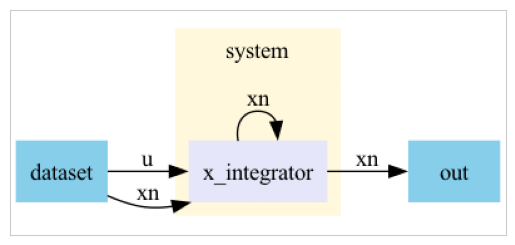

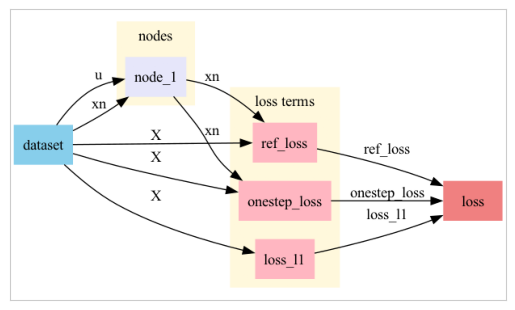

None


In [7]:

from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators


# One-element integrator for current state
integrator_x = integrators.Euler(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.show()

x = variable(f"X")
x_hat = variable(f'xn')[:, :-1, :]

# Define losses
onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
onestep_loss_x.name = "onestep_loss"

reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
reference_loss_x.name = "ref_loss"

# L1 sparsity regularization on model weights
l1_x = variable([x], lambda x: sum(torch.norm(p, p=1) for p in sindy.Xi))
loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
loss_l1_x.name = "loss_l1"

# Assemble problem
objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
loss_x = PenaltyLoss(objectives_x, [])
problem_x = Problem([dynamics_model_x], loss_x)
problem_x.show()

lr = dyn_cfg["lr"]
optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

logger = CustomLogger(
    args=None,
    savedir='test',
    verbosity=200,
    stdout=['train_loss','dev_loss']
)




In [484]:

trainer_x = SparseTrainer(
    problem=problem_x,
    sindy=sindy,
    lr=lr,
    train_data=None,
    test_data=None,
    optimizers=optimizer_x,
    epochs=dyn_cfg["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=logger,
    device= device,
    threshold=dyn_cfg["threshold"],
    prune_every=dyn_cfg["prune_every"],
    warmup=300,
    patience=50,
    threshold_mult=dyn_cfg["threshold_mult"],
    prune_noise=dyn_cfg["prune_noise"],
    l1_decay=dyn_cfg["l1_decay"],
)

# Regenerate training data for updated horizon
trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
trainer_x.problem = problem_x

# Train
best_model = trainer_x.train()
trainer_x.model.load_state_dict(best_model)


epoch: 0	train_loss: 2.044e+02	dev_loss: 1.288e+02	eltime:  0.15059
epoch: 200	train_loss: 3.787e-03	dev_loss: 5.440e-02	eltime:  16.72841
epoch: 400	train_loss: 1.897e-03	dev_loss: 3.428e-02	eltime:  31.28666
epoch: 600	train_loss: 1.085e-03	dev_loss: 2.081e-02	eltime:  45.87783
epoch: 800	train_loss: 6.281e-04	dev_loss: 1.344e-02	eltime:  60.46206
epoch: 1000	train_loss: 4.073e-04	dev_loss: 9.178e-03	eltime:  75.15640
epoch: 1200	train_loss: 2.737e-04	dev_loss: 6.505e-03	eltime:  89.71857
epoch: 1400	train_loss: 2.428e-04	dev_loss: 5.074e-03	eltime:  104.27383
epoch: 1600	train_loss: 1.303e-04	dev_loss: 3.452e-03	eltime:  118.84096
epoch: 1800	train_loss: 9.117e-05	dev_loss: 2.524e-03	eltime:  133.40780
epoch: 2000	train_loss: 1.092e-04	dev_loss: 1.895e-03	eltime:  148.11450
epoch: 2200	train_loss: 4.635e-05	dev_loss: 1.314e-03	eltime:  162.66850
epoch: 2400	train_loss: 3.437e-05	dev_loss: 9.386e-04	eltime:  177.28274
epoch: 2600	train_loss: 2.660e-05	dev_loss: 7.011e-04	eltime:  191

<All keys matched successfully>

In [485]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1
dx1/dt = -1.9802e-01·x1 + +9.9004e-01·u0
dx2/dt = +1.0000e+00·x3
dx3/dt = -1.9800e-01·x3 + +9.9007e-01·u1


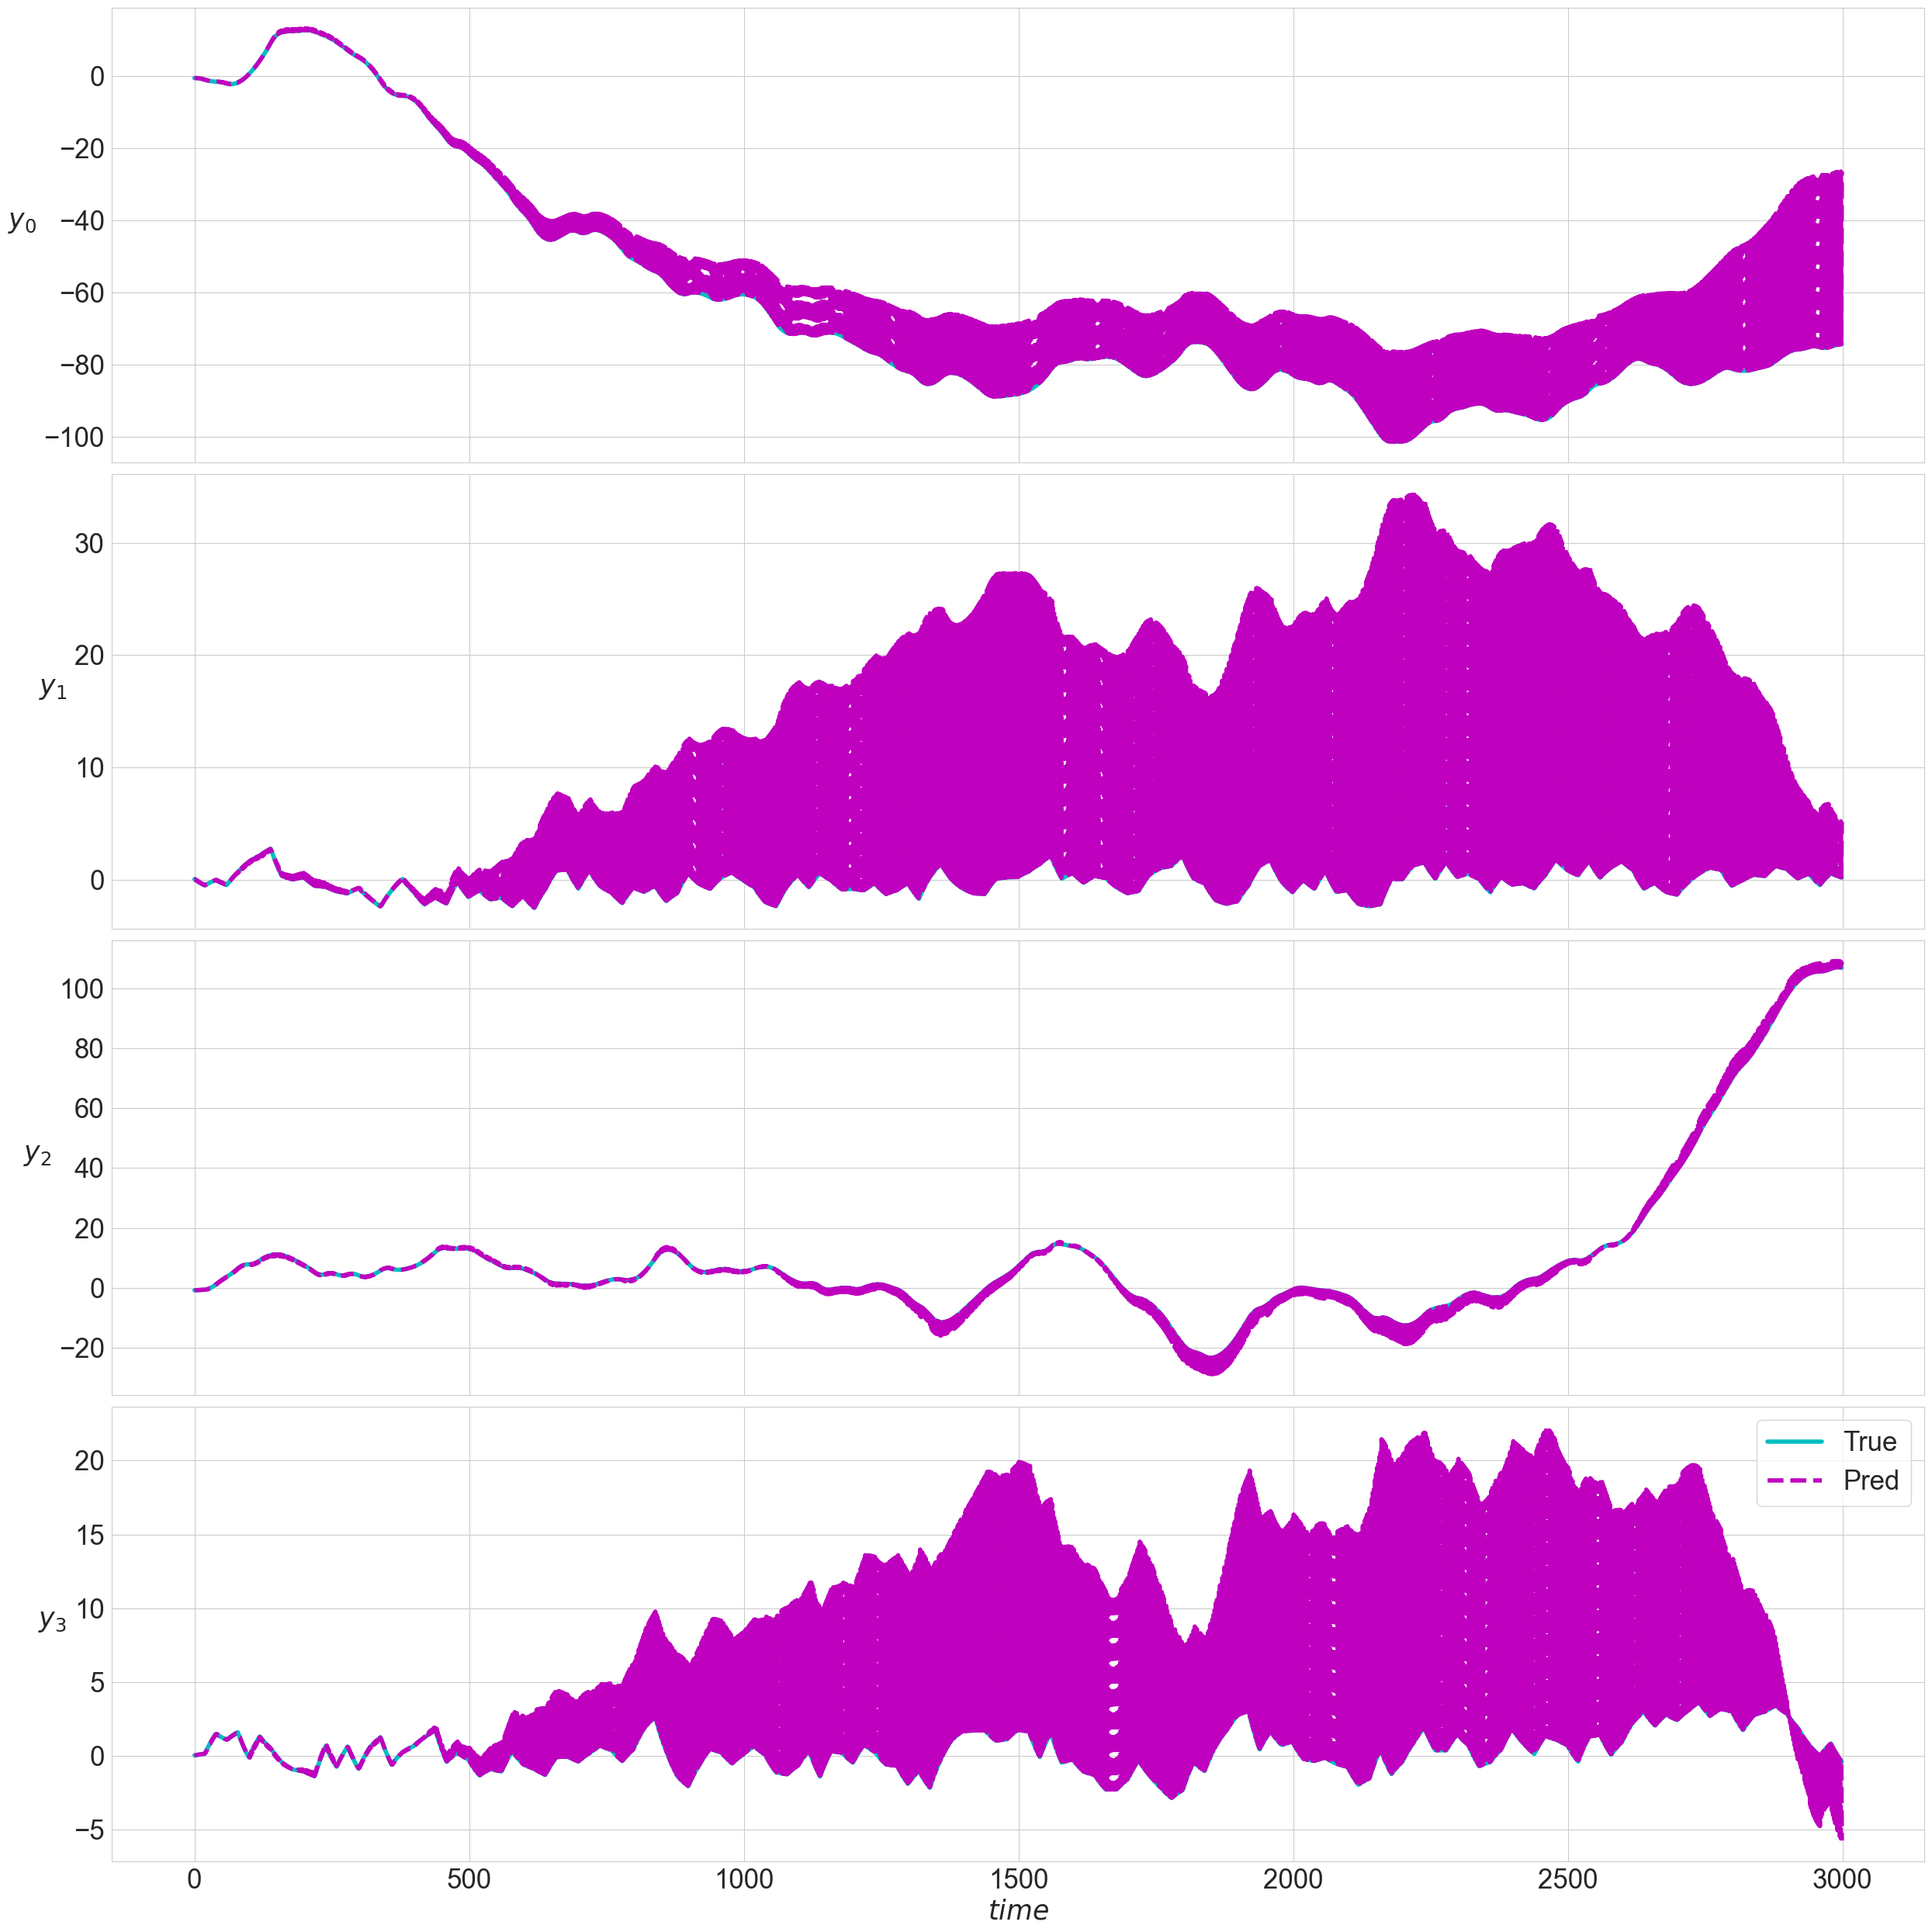

In [8]:
import matplotlib.pyplot as plt

# Create system for evaluation
sindy_system = System([integrator_node_x], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


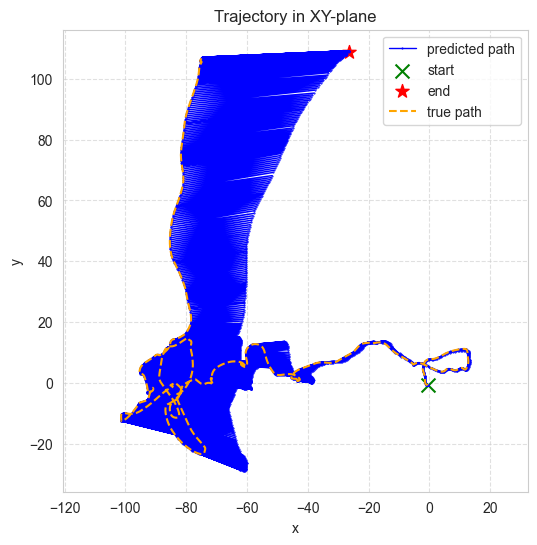

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
def plot_traj(pred_traj, true_traj=None, title="Trajectory in XY-plane"):
    """
    pred_traj: numpy array of shape (4, T)
               rows: [x, xdot, y, ydot]
    true_traj: numpy array of shape (4, T) (optional)
    """
    x_pred = pred_traj[0, :]
    y_pred = pred_traj[2, :]

    plt.figure(figsize=(6,6))
    # predicted
    plt.plot(x_pred, y_pred, marker="o", markersize=0.5, linewidth=1.0,
             label="predicted path", color="blue")
    plt.scatter(x_pred[0], y_pred[0], c="green", marker="x", s=100, label="start")
    plt.scatter(x_pred[-1], y_pred[-1], c="red", marker="*", s=100, label="end")

    # true path if given
    if true_traj is not None:
        x_true = true_traj[0, :]
        y_true = true_traj[2, :]
        plt.plot(x_true, y_true, linewidth=1.5, linestyle="--", color="orange", label="true path")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

# Example:
plot_traj(pred_traj, true_traj)


In [10]:
# import json, torch
# from pathlib import Path
#
# sindy_lib_cfg = dict(
#     n_features=lib.n_features,
#     n_control=lib.n_control,
#     include_bias=lib.include_bias,
#     max_degree=lib.max_degree,
#     add_sqrt=lib.add_sqrt,
#     add_xu=lib.add_xu,
#     add_u_prod=lib.add_u_prod,
#     add_fourier=lib.add_fourier,
#     max_freq=lib.max_freq,
#     is_policy=lib.is_policy,
# )
#
# sindy_model_cfg = dict(
#     n_out=sindy.n_out,
# )
#
# ckpt = {
#     "lib_cfg": sindy_lib_cfg,
#     "model_cfg": sindy_model_cfg,
#     "active_idx": sindy.active_idx,          # list[list[int]]
#     "state_dict": sindy.state_dict(),        # weights
# }
#
#
# # ---------------- user-supplied objects & constants ------------------------ #
# base_dir       = "results/tests/dynamics"
# # --------------------------------------------------------------------------- #
#
# run_id  = 1
# while Path(base_dir, f"run_{run_id}").exists():
#     run_id += 1
# run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
# (Path(run_dir, "run_config.json")
#  .write_text(json.dumps(dyn_cfg, indent=4)))
#
# models_dir = run_dir / "saved_models"; models_dir.mkdir()
# torch.save(ckpt, str(models_dir) + "/sindy.pt")   # you can call it .pkl if you want


In [11]:
import torch
import torch.nn as nn

import torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/sindy.pt", map_location=device)

# Rebuild library and model skeleton
lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
sindy = SINDyVectorized(
    library=lib,
    n_out=ckpt["model_cfg"]["n_out"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
sindy.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(sindy.active_idx):
    sindy.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
sindy._plan = sindy._recompile_fast_path(device=device)

# Load weights
sindy.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_6326/4175866234.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/sindy.pt

<All keys matched successfully>

In [12]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1
dx1/dt = -1.9802e-01·x1 + +9.9004e-01·u0
dx2/dt = +1.0000e+00·x3
dx3/dt = -1.9800e-01·x3 + +9.9007e-01·u1


### Policy dataset with obstacle exclusion

- Builds train/dev `DataLoader`s for policy learning.
- Samples initial states (`xn`) and constant references (`r`) from rectangles.
- Rejects points inside ellipse:
  \( b(x-c)^2 + (y-d)^2 \ge (p/2)^2 \).

**Main steps**
- RNG split via `seed` (train/dev).
- `sample_xy_in_rect_outside`: uniform rect sampling with ellipse rejection.
- `_build_split`:
  - `xn`: positions + zero velocities.
  - `r`: constant ref over horizon.
  - Add obstacle params.

**Outputs**
- `train_loader`, `dev_loader` with dicts:
  - `"xn"` (B,1,nx), `"r"` (B,nsteps+1,2), `"obs_*"`.


In [15]:
ellipse_configs = {"p": 0.6,
                   "b": 1,
                   "c": 0.0,
                   "d": 0.0,
                   "theta": 0.0}

def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

side = 0.5   # for example, 0.5 x 0.5 squares

# initial region center
init_center = (0.6, -0.6)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-0.6, 0.6)
ref_rect = make_square(ref_center, side)

nsteps = 50
xmin = -1.
xmax = 1.
umin = -2.
umax = 2.

train_loader, dev_loader = get_policy_data(
    nsteps=nsteps, n_samples=3000, nx=nx, batch_size=200 ,device=device,
    ellipse_configs=ellipse_configs,
    init_rect=init_rect, ref_rect=ref_rect,
)


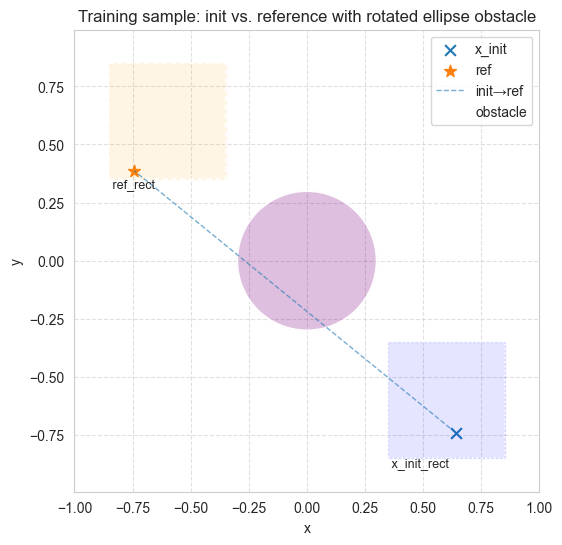

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Training sample: init vs. reference with rotated ellipse obstacle'}, xlabel='x', ylabel='y'>)

In [16]:
# plotting a data sample from train loader
plot_training_sample_with_ellipse(
    train_loader,
    sample_idx=32,
    pos_idx=(0, 2),
    init_rect=init_rect,
    ref_rect=ref_rect,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    theta=ellipse_configs["theta"],
    xmin=-1., xmax=1.
)

In [27]:
from SparseDPC.vectorized.utils import DoubleIntegrator2DParam

double_integrator = DoubleIntegrator2DParam()
double_integrator.mx = torch.nn.Parameter(torch.tensor(gt_model.mx), requires_grad=False)
double_integrator.my = torch.nn.Parameter(torch.tensor(gt_model.my), requires_grad=False)
double_integrator.cx = torch.nn.Parameter(torch.tensor(gt_model.cx), requires_grad=False)
double_integrator.cy = torch.nn.Parameter(torch.tensor(gt_model.cy), requires_grad=False)
double_integrator.kx = torch.nn.Parameter(torch.tensor(gt_model.kx), requires_grad=False)
double_integrator.ky = torch.nn.Parameter(torch.tensor(gt_model.ky), requires_grad=False)

pol_configs = {
    "l1_coef": 0.0002,
    "Q_con_obs": 100.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 0.01,
    "Q_uf": 2.0,
    "Q_v": 2.0,
    "Q_r": 3.0,
    "Q_dx": 0.0,
    "Q_du": 0.0001,
    "lr": 0.002,
    "epochs": 10000,
    "threshold": 0.08,
    "prune_every": 2000,
    "prune_every_min": 300,
    "prune_every_decay": 200,
    "change_prune_every": True,
    "threshold_mult": 1.3,
    "threshold_max" : 0.12,
    "prune_noise": 0.01,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
}

refstep=1
policies_seed = 0


None


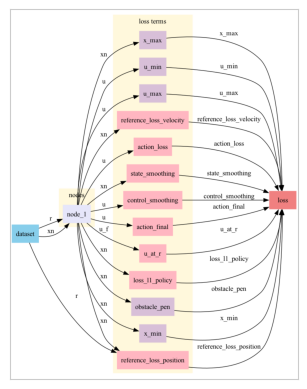

In [28]:
# build library once
policy_lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=True,
    include_bias=False, max_degree=2,
    add_sqrt=True, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
policy_sparse = SINDyVectorized(library=policy_lib, n_out=nu, policy_name=["u0","u1"], device=device, seed=policies_seed)

builder_SD_SINDy = SparsePolicyBuilder2D(
    dynamics_model= sindy,
    policy        = policy_sparse,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    obstacle_configs = ellipse_configs,
    refstep = refstep,
    seed          = policies_seed,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [29]:
builder_SD_SINDy.policy.pretty_print()

u0 = -3.7434e-04·x0 + +2.6822e-02·x1 + -4.1152e-02·x2 + -3.6797e-02·x3 + -1.9258e-02·r0 + +1.3408e-02·r1 + -9.9066e-04·sqrt(x0) + +3.9644e-02·sqrt(x1) + -4.4372e-03·sqrt(x2) + +1.3231e-02·sqrt(x3) + -1.5111e-02·x0^2 + -9.8283e-03·x0*x1 + -4.7767e-02·x0*x2 + -3.3114e-02·x0*x3 + -2.0611e-02·x1^2 + +1.8522e-03·x1*x2 + +1.9767e-02·x1*x3 + +3.0001e-02·x2^2 + -3.3897e-02·x2*x3 + -2.1773e-02·x3^2 + +1.8161e-02·r0*r1 + +4.1519e-02·x0*r0 + -1.0290e-02·x0*r1 + +3.7416e-02·x1*r0 + -8.0592e-03·x1*r1 + +5.2907e-03·x2*r0 + +4.5274e-02·x2*r1 + -4.6384e-02·x3*r0 + -3.1477e-02·x3*r1
u1 = -1.2658e-02·x0 + -1.9490e-02·x1 + +4.3200e-02·x2 + -3.2409e-02·x3 + -2.3017e-02·r0 + -3.4932e-02·r1 + -4.6828e-02·sqrt(x0) + -2.9187e-02·sqrt(x1) + +4.2980e-02·sqrt(x2) + +2.2311e-02·sqrt(x3) + +2.4234e-02·x0^2 + +2.6296e-03·x0*x1 + -2.5634e-02·x0*x2 + +8.4592e-03·x0*x3 + -4.6685e-02·x1^2 + -3.6128e-02·x1*x2 + -2.5776e-02·x1*x3 + +3.1547e-02·x2^2 + +2.9316e-02·x2*x3 + -2.2175e-02·x3^2 + -1.8041e-03·r0*r1 + +3.1978e-02·

In [30]:
builder_SD_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 2.051e+00	dev_loss: 1.790e+00	eltime:  2.13660
epoch: 10	train_loss: 1.959e-01	dev_loss: 2.060e-01	eltime:  11.63990
epoch: 20	train_loss: 1.061e-01	dev_loss: 1.102e-01	eltime:  21.16642
epoch: 30	train_loss: 7.311e-02	dev_loss: 7.544e-02	eltime:  30.74442
epoch: 40	train_loss: 5.470e-02	dev_loss: 5.601e-02	eltime:  40.13938
epoch: 50	train_loss: 4.284e-02	dev_loss: 4.368e-02	eltime:  49.61133
epoch: 60	train_loss: 3.470e-02	dev_loss: 3.525e-02	eltime:  59.08870
epoch: 70	train_loss: 2.898e-02	dev_loss: 2.926e-02	eltime:  68.60219
epoch: 80	train_loss: 2.472e-02	dev_loss: 2.496e-02	eltime:  78.06471
epoch: 90	train_loss: 2.154e-02	dev_loss: 2.174e-02	eltime:  87.47599
epoch: 100	train_loss: 1.911e-02	dev_loss: 1.931e-02	eltime:  96.85766
epoch: 110	train_loss: 1.719e-02	dev_loss: 1.741e-02	eltime:  106.30632
epoch: 120	train_loss: 1.573e-02	dev_loss: 1.586e-02	eltime:  115.71613
epoch: 130	train_loss: 1.454e-02	dev_loss: 1.462e-02	eltime:  125.08220
epoch: 140	trai

In [31]:
policy_sparse.pretty_print()
print(policy_sparse.coef)

u0 = -4.2396e-01·x1 + -1.8526e-01·x3 + +9.6821e-01·x0*x1 + -1.6121e+00·x2*x3 + -1.3003e+00·x0*r1 + -5.3237e-01·x1*r0 + -2.2401e+00·x1*r1 + +1.3056e+00·x2*r0 + +1.1294e+00·x3*r0
u1 = +3.3963e-01·x1 + -1.1337e+00·x2 + -1.5985e+00·x3 + -2.8207e-01·r0 + +1.2288e+00·r1 + +2.4717e-01·sqrt(x0) + -1.7541e-01·sqrt(x2) + -2.3322e-01·x0^2 + +2.2926e-01·x0*x3
tensor([[ 0.0000,  0.0000],
        [-0.4240,  0.3396],
        [ 0.0000, -1.1337],
        [-0.1853, -1.5985],
        [ 0.0000, -0.2821],
        [ 0.0000,  1.2288],
        [ 0.0000,  0.2472],
        [ 0.0000,  0.0000],
        [ 0.0000, -0.1754],
        [ 0.0000,  0.0000],
        [ 0.0000, -0.2332],
        [ 0.9682,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.2293],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [-1.6121,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [-1.3003,  0.0000],
      

In [37]:

import json, torch
from pathlib import Path

policy_lib_cfg = dict(
    n_features=policy_lib.n_features,
    n_control=policy_lib.n_control,
    include_bias=policy_lib.include_bias,
    max_degree=policy_lib.max_degree,
    add_sqrt=policy_lib.add_sqrt,
    add_xu=policy_lib.add_xu,
    add_u_prod=policy_lib.add_u_prod,
    add_fourier=policy_lib.add_fourier,
    max_freq=policy_lib.max_freq,
    is_policy=policy_lib.is_policy,
)

policy_model_cfg = dict(
    n_out=policy_sparse.n_out,
    policy_name=policy_sparse.policy_name,
)

ckpt = {
    "lib_cfg": policy_lib_cfg,
    "model_cfg": policy_model_cfg,
    "active_idx": policy_sparse.active_idx,          # list[list[int]]
    "state_dict": policy_sparse.state_dict(),        # weights
}

builders       = {"SINDy": builder_SD_SINDy}   # tag → builder
base_dir       = "results/tests/sparse"
# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()
    torch.save(ckpt, str(models_dir) + "/policy_sparse.pt")   # you can call it .pkl if you want


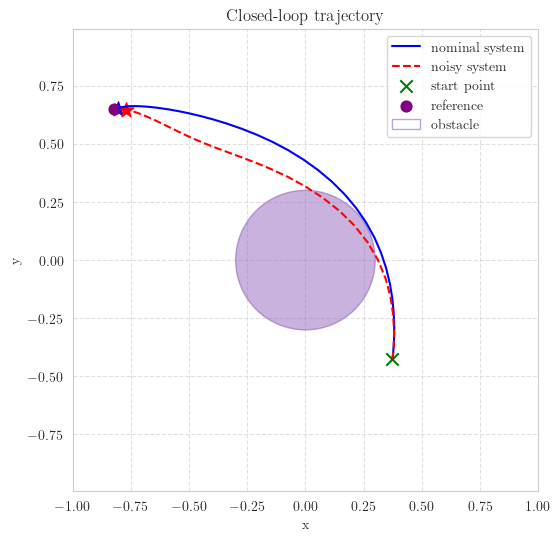

In [40]:
# Closed-loop simulation setup
import copy

nsteps_test = 50
data = make_test_sample(
    nx=nx, nsteps=nsteps_test, seed= 65
    , device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)


double_integrator_noisy = DoubleIntegrator2DParam()
double_integrator_noisy.mx = torch.nn.Parameter(torch.tensor(gt_model.mx - 0.5), requires_grad=False)
double_integrator_noisy.cx = torch.nn.Parameter(torch.tensor(gt_model.cx - 0.1), requires_grad=False)
double_integrator_noisy.my = torch.nn.Parameter(torch.tensor(gt_model.my - 0.5), requires_grad=False)
double_integrator_noisy.cy = torch.nn.Parameter(torch.tensor(gt_model.cy - 0.1), requires_grad=False)


gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

gt_integrator_noisy = integrators.Euler(double_integrator_noisy, h=torch.tensor(ts))
gt_integrator_node_noisy = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')


policy_node = Node(
            lambda xn,r : torch.clamp(builder_SD_SINDy.policy(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([policy_node, gt_integrator_node_noisy]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps_test
gt_sindy_policy_system_noisy.nsteps = nsteps_test

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


In [ ]:

# -------------------- Example call --------------------
# your sample dict:
xmin = -1.
xmax = 1.
umin = -2.
umax = 2.
sample = make_test_sample(
    nx=4, nsteps=50, seed= 31, device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)
scale = 1.
pol_configs = {
    "l1_coef": 0.008,
    "Q_con_obs": scale * 1e2,
    "Q_con_x": scale * 10.0,
    "Q_con_u": scale * 10.0,
    "Q_u": 0.001,
    "Q_r": 1.0,
    "Q_dx": scale * 0.0000,
    "Q_du": scale * 0.0001,
}
refstep=1

bounds = dict(xmin=xmin, xmax=xmax, umin=umin, umax=umax)

Xsol, Usol, J, fig_xy, fig_ts = solve_and_plot_ipopt(
    sample, pol_configs,
    ts=0.1,
    ellipse_cfg=ellipse_configs,
    bounds=bounds,
    use_msd=True,       # set True and pass m,k,c for MSD dynamics
    m=1.0, k=0.0, c=0.2,
    track_whole_horizon=False,
    refstep = refstep,
    add_state_smoothing=True,
    add_control_smoothing=True,
    title_xy="IPOPT plan (double integrator)"
)
plt.show()
